In [1]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

from scipy.stats import pearsonr # Correlation

In [2]:
# Load datasets
df_manu =  pl.read_parquet(f'../Experiment/Knee/data/interim/2.1-train.parquet')
df_mice = pl.read_parquet(f'../Experiment/Knee/data/interim/2.2-train.parquet')


In [3]:
df_manu.columns

['Provider Code',
 'Procedure',
 'Revision Flag',
 'Year',
 'Age Band',
 'Gender',
 'Pre-Op Q Assisted',
 'Pre-Op Q Assisted By',
 'Pre-Op Q Symptom Period',
 'Pre-Op Q Previous Surgery',
 'Pre-Op Q Living Arrangements',
 'Pre-Op Q Disability',
 'Heart Disease',
 'High Bp',
 'Stroke',
 'Circulation',
 'Lung Disease',
 'Diabetes',
 'Kidney Disease',
 'Nervous System',
 'Liver Disease',
 'Cancer',
 'Depression',
 'Arthritis',
 'Pre-Op Q Mobility',
 'Pre-Op Q Self-Care',
 'Pre-Op Q Activity',
 'Pre-Op Q Discomfort',
 'Pre-Op Q Anxiety',
 'Pre-Op Q EQ5D Index Profile',
 'Pre-Op Q EQ5D Index',
 'Post-Op Q EQ5D Index Profile',
 'Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q 

In [4]:
# Variables to compare
vars_to_compare = [
    'health_gain',
    'Age Band',
    'Gender',
    'Revision Flag',
    'Procedure',
    # Pre-Op Q variables
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    # Knee-specific Pre-Op Q variables
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs',
    'Knee Replacement Pre-Op Q Score',
    # Comorbidities
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

# Select only relevant columns
df_manu  = df_manu.select(vars_to_compare)
df_mice = df_mice.select(vars_to_compare)

In [5]:
# --- Missingness comparison ---

# Count missing values in each dataset
missing_manu = (
    df_manu.null_count()
    .melt(variable_name="variable", value_name="missing_manu")
)

missing_mice = (
    df_mice.null_count()
    .melt(variable_name="variable", value_name="missing_mice")
)

# Join results side-by-side
missing_compare = missing_manu.join(missing_mice, on="variable")

print("=== Missingness Comparison ===")
print(missing_compare)


=== Missingness Comparison ===
shape: (41, 3)
┌────────────────┬──────────────┬──────────────┐
│ variable       ┆ missing_manu ┆ missing_mice │
│ ---            ┆ ---          ┆ ---          │
│ str            ┆ u32          ┆ u32          │
╞════════════════╪══════════════╪══════════════╡
│ health_gain    ┆ 0            ┆ 0            │
│ Age Band       ┆ 0            ┆ 0            │
│ Gender         ┆ 0            ┆ 0            │
│ Revision Flag  ┆ 0            ┆ 0            │
│ Procedure      ┆ 0            ┆ 0            │
│ …              ┆ …            ┆ …            │
│ Nervous System ┆ 0            ┆ 0            │
│ Liver Disease  ┆ 0            ┆ 0            │
│ Cancer         ┆ 0            ┆ 0            │
│ Depression     ┆ 0            ┆ 0            │
│ Arthritis      ┆ 0            ┆ 0            │
└────────────────┴──────────────┴──────────────┘


C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\477845598.py:6: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_manu")
C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\477845598.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_mice")


In [6]:
# --- Identify numeric and categorical variables ---
numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs',
    'Knee Replacement Pre-Op Q Score'
]

categorical_vars = [
    'Age Band','Gender','Revision Flag','Procedure',
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

In [7]:
# --- Summary statistics for numeric variables ---

stats_manu = df_manu.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_manu")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_manu")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_manu")
        for v in numeric_vars
    ]
)

stats_mice = df_mice.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_mice")
        for v in numeric_vars
    ]
)

print("=== Numeric Summary Statistics: MANU ===")
print(stats_manu)

print("=== Numeric Summary Statistics: MICE ===")
print(stats_mice)


=== Numeric Summary Statistics: MANU ===
shape: (1, 75)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_m ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ anu       ┆ mean_manu ┆ By_mean_m ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ anu       ┆ an_m…     ┆   ┆ Conf…     ┆ Shop…     ┆ Stai…     ┆ Scor…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.990746 ┆ 1.847837  ┆ 1.0       ┆ 2.595886  ┆ … ┆ 2.0       ┆ 2.0       ┆ 2.0       ┆ 19.0     │
└───────────┴───────────┴──────────

In [8]:
# --- Simple value counts for categorical variables ---

for col in categorical_vars:
    print(f"\n=== Value Counts for {col} ===")
    
    print("MANU:")
    print(df_manu[col].value_counts())
    
    print("MICE:")
    print(df_mice[col].value_counts())


=== Value Counts for Age Band ===
MANU:
shape: (6, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ i32      ┆ u32   │
╞══════════╪═══════╡
│ 4        ┆ 39970 │
│ 6        ┆ 19    │
│ 3        ┆ 33362 │
│ 2        ┆ 9831  │
│ 5        ┆ 11183 │
│ 1        ┆ 185   │
└──────────┴───────┘
MICE:
shape: (7_514, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 3.528563 ┆ 1     │
│ 3.469496 ┆ 1     │
│ 3.537517 ┆ 1     │
│ 3.331678 ┆ 1     │
│ 3.712759 ┆ 1     │
│ …        ┆ …     │
│ 3.80387  ┆ 1     │
│ 3.902154 ┆ 1     │
│ 3.982148 ┆ 1     │
│ 3.968629 ┆ 1     │
│ 4.294889 ┆ 1     │
└──────────┴───────┘

=== Value Counts for Gender ===
MANU:
shape: (2, 2)
┌────────┬───────┐
│ Gender ┆ count │
│ ---    ┆ ---   │
│ f32    ┆ u32   │
╞════════╪═══════╡
│ 2.0    ┆ 53589 │
│ 1.0    ┆ 40961 │
└────────┴───────┘
MICE:
shape: (7_510, 2)
┌──────────┬───────┐
│ Gender   ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │

=== Summary Statistics: MANU ===
shape: (1, 125)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_m ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ anu       ┆ mean_manu ┆ By_mean_m ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ anu       ┆ an_m…     ┆   ┆ Conf…     ┆ Shop…     ┆ Stai…     ┆ Scor…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.990746 ┆ 1.847837  ┆ 1.0       ┆ 2.595886  ┆ … ┆ 3.0       ┆ 3.0       ┆ 2.0       ┆ 24.0     │
└───────────┴───────────┴───────────┴─────

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


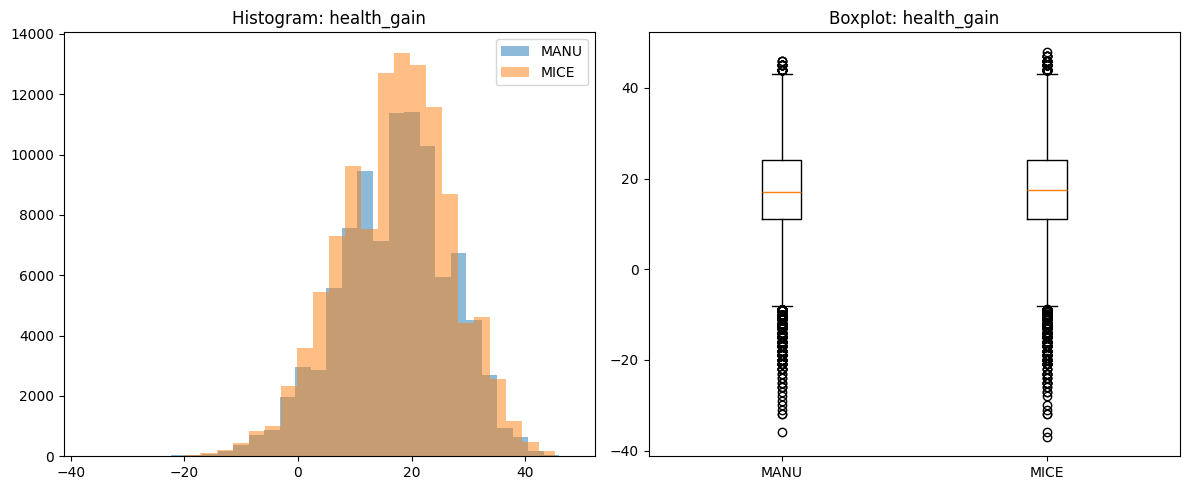

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


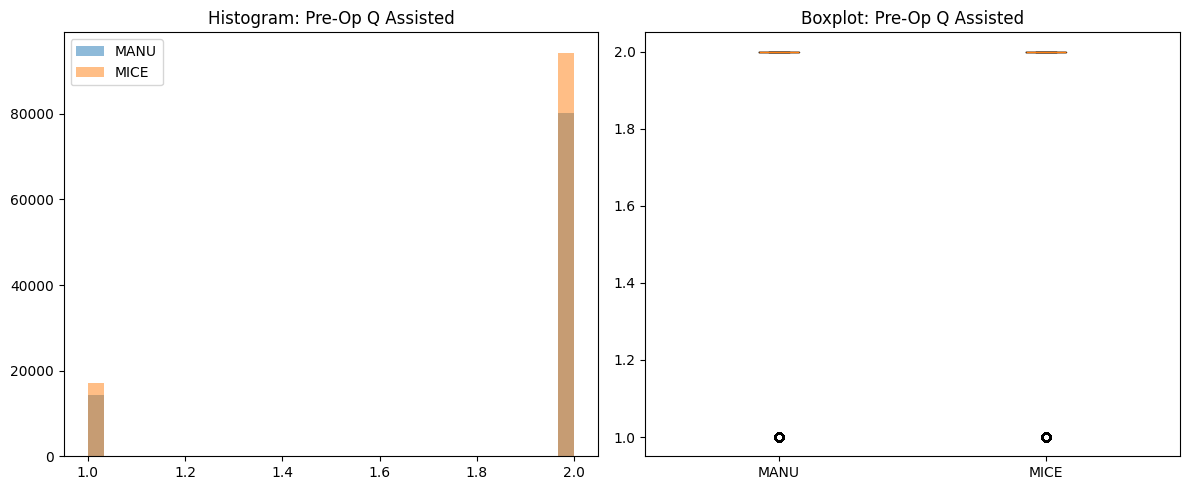

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


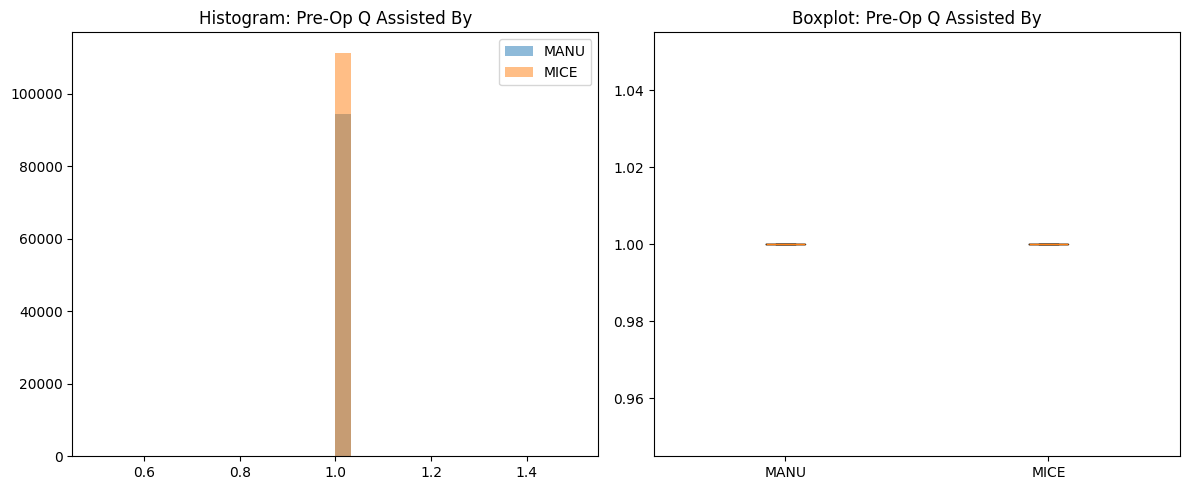

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


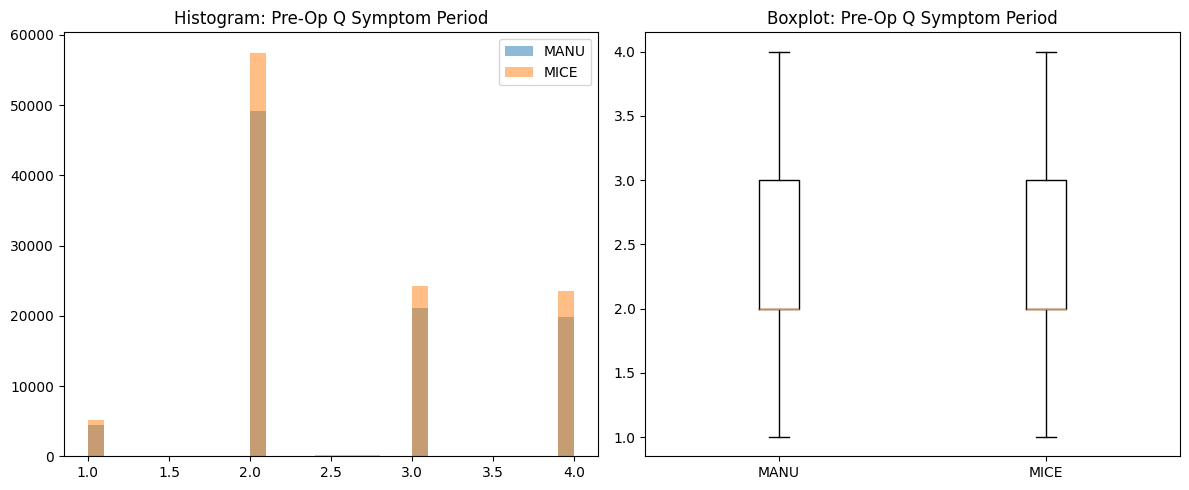

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


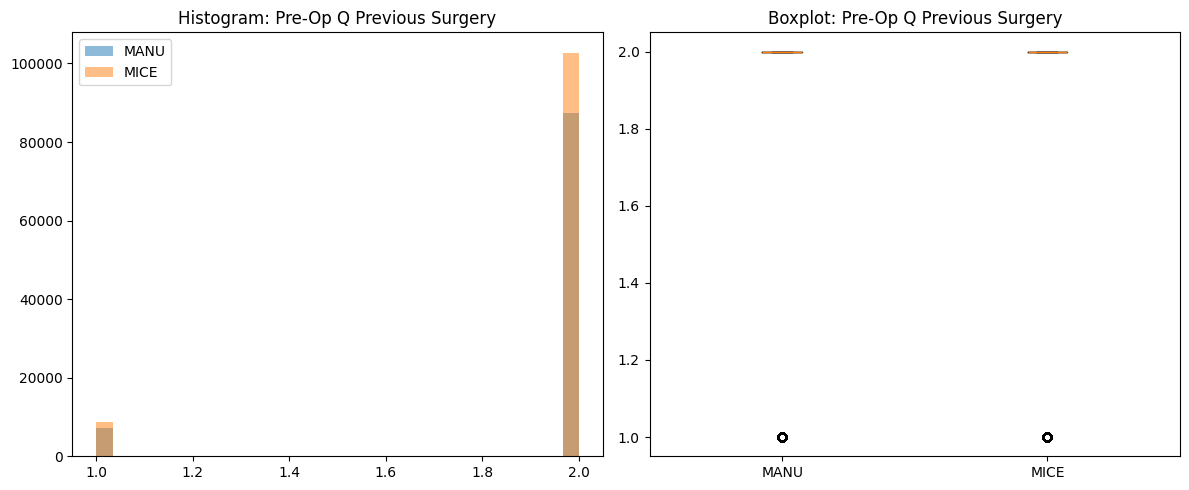

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


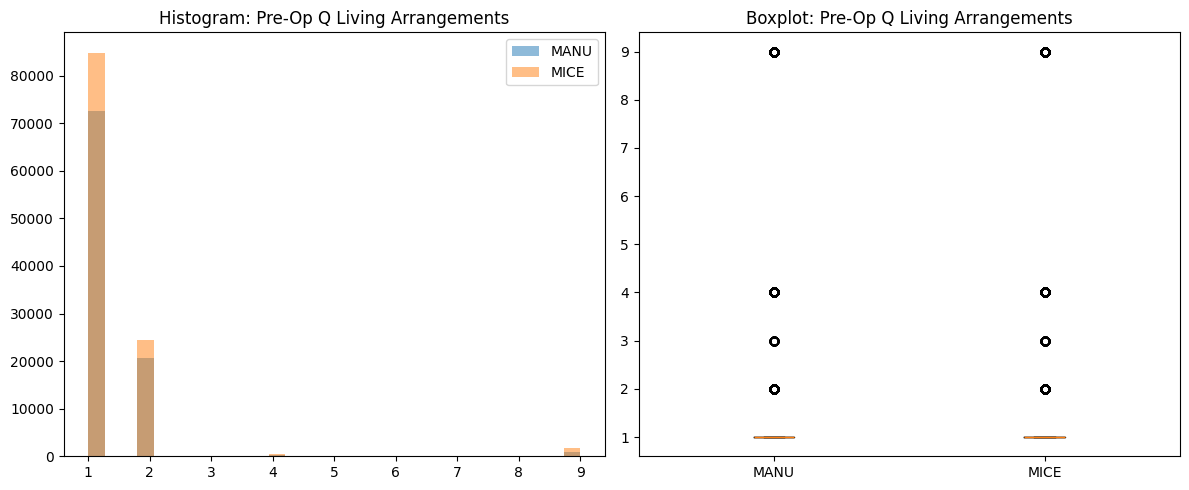

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


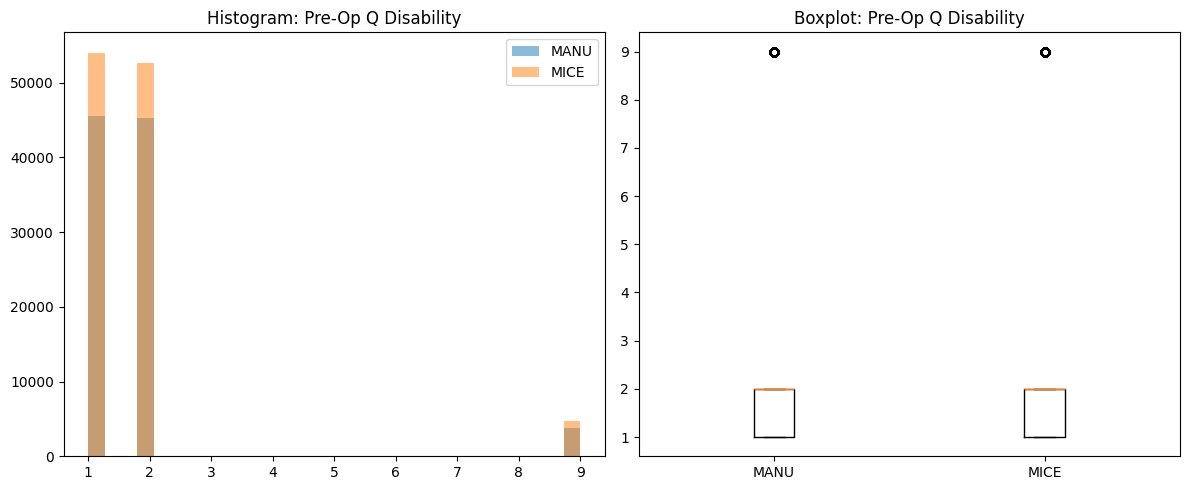

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


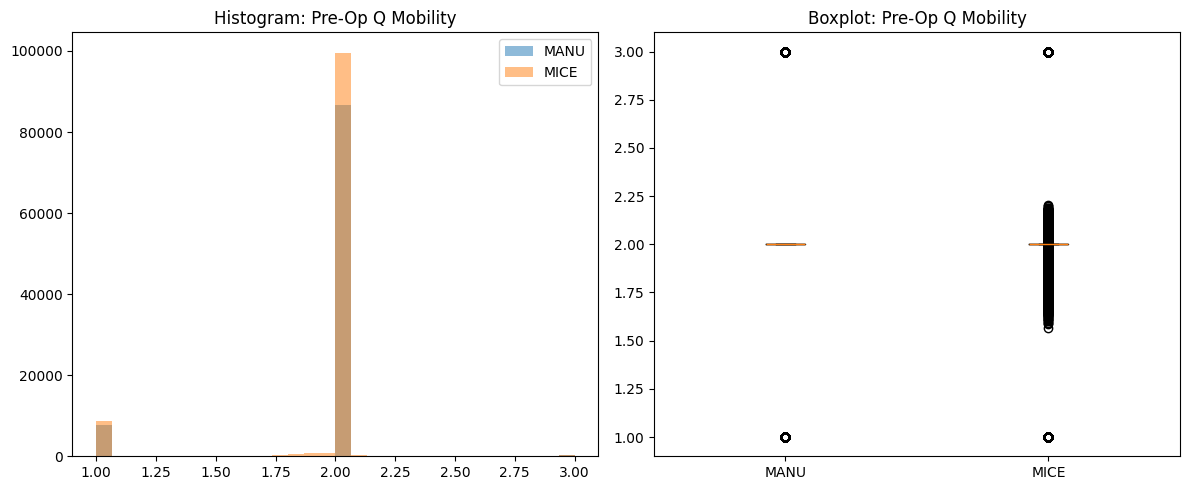

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


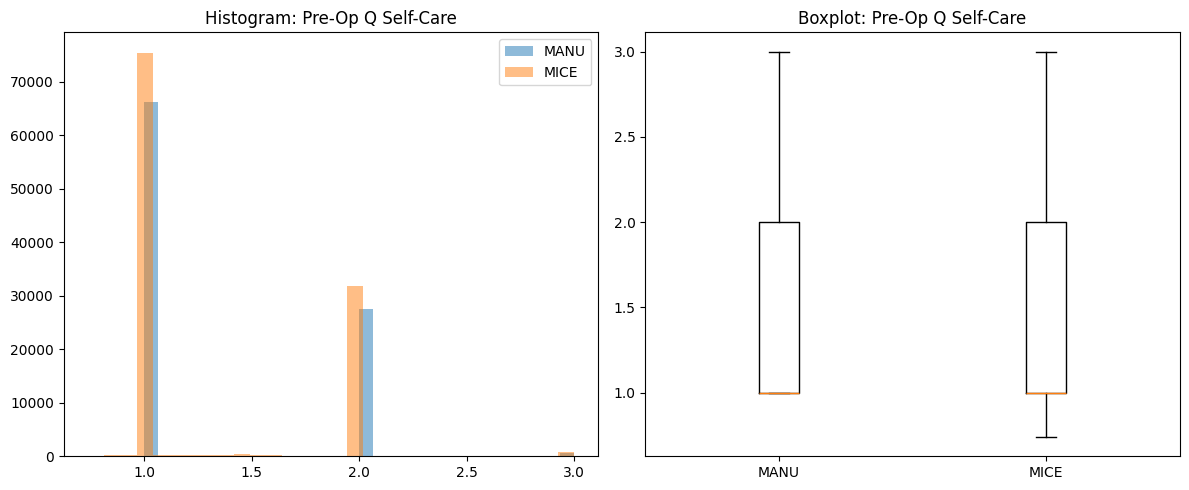

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


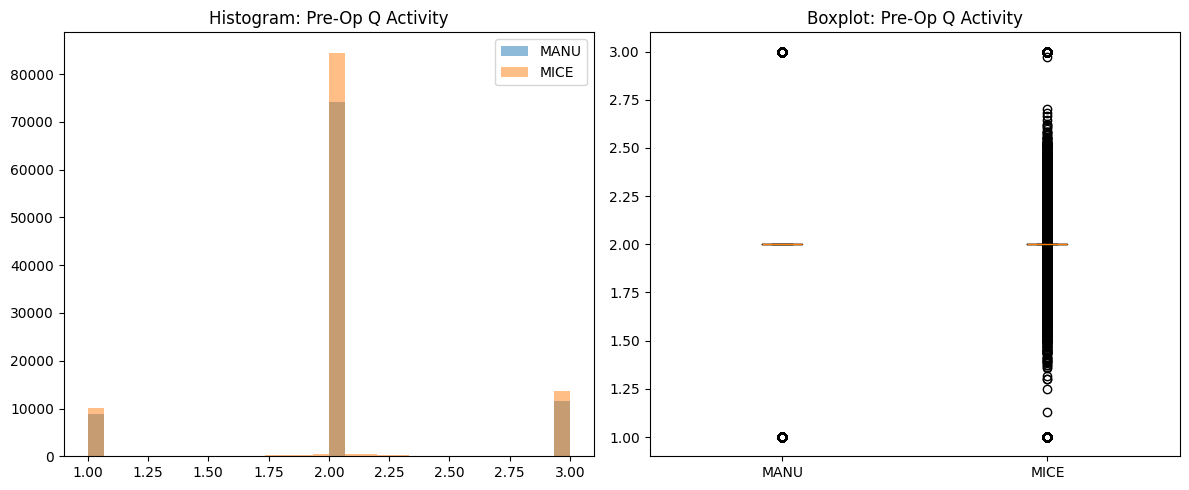

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


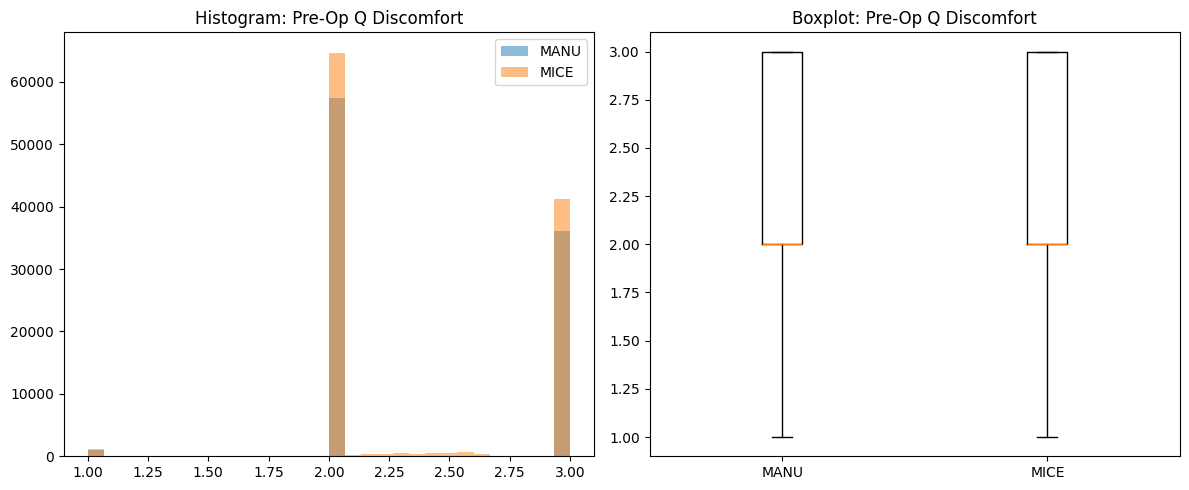

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


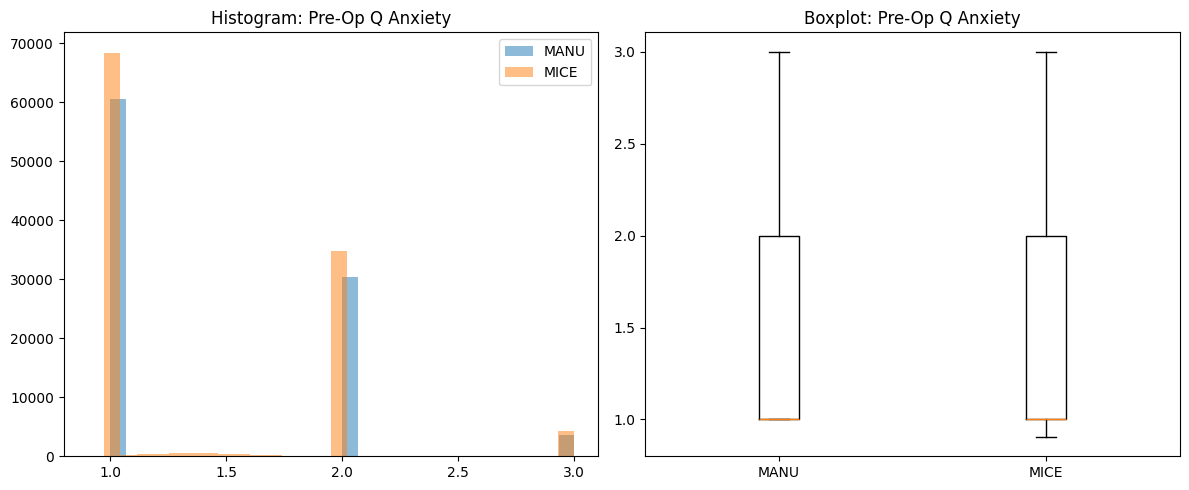

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


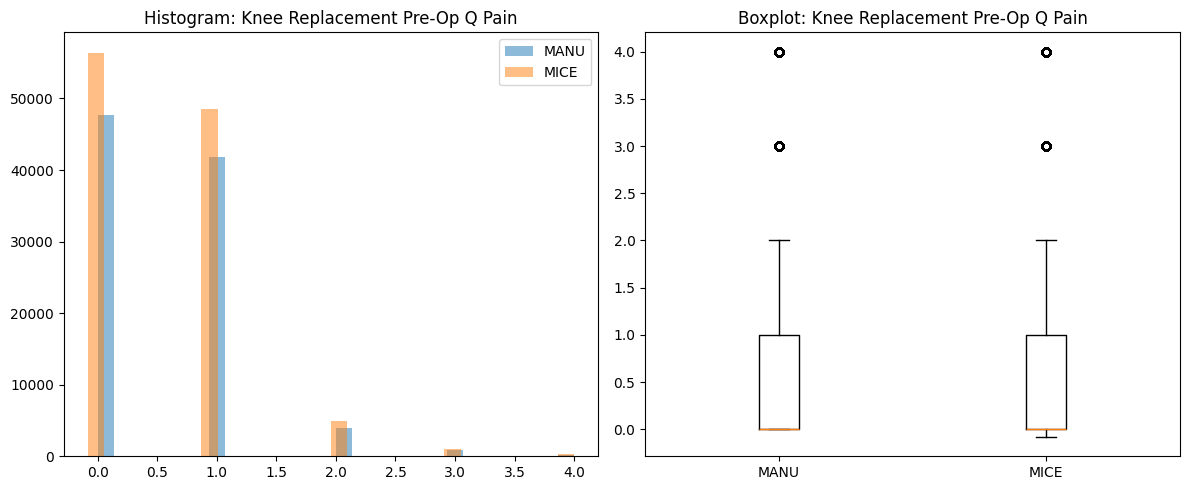

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


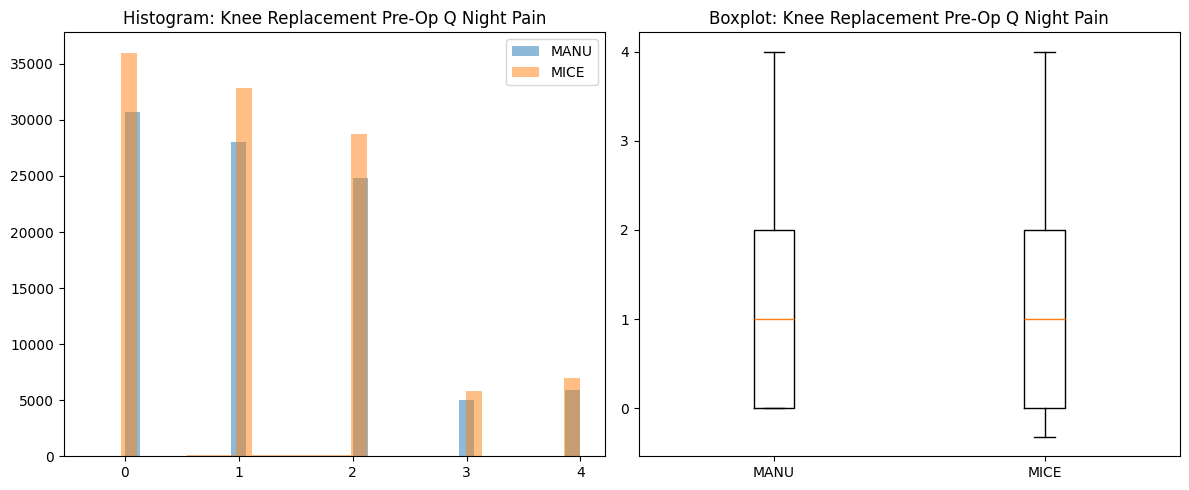

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


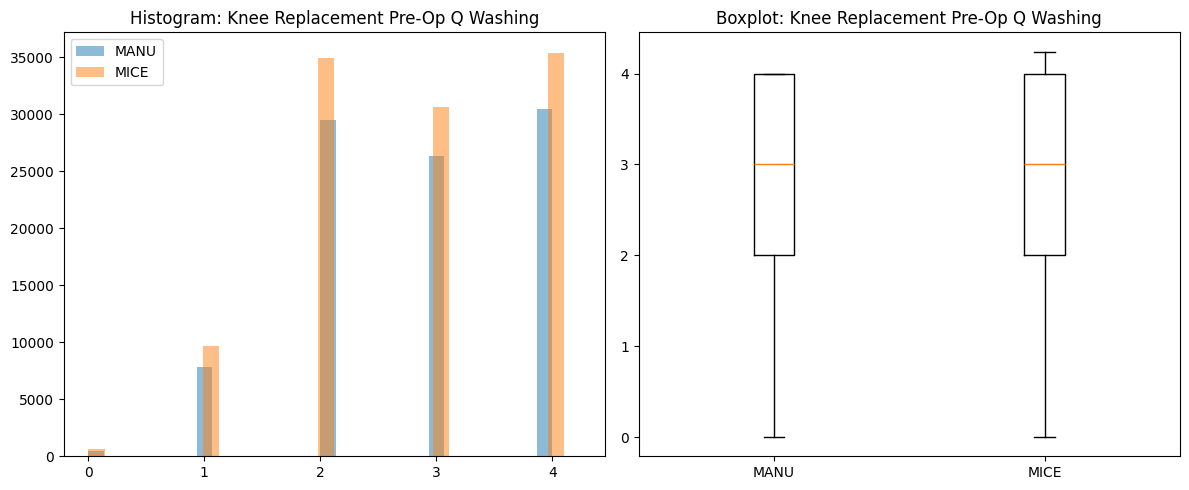

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


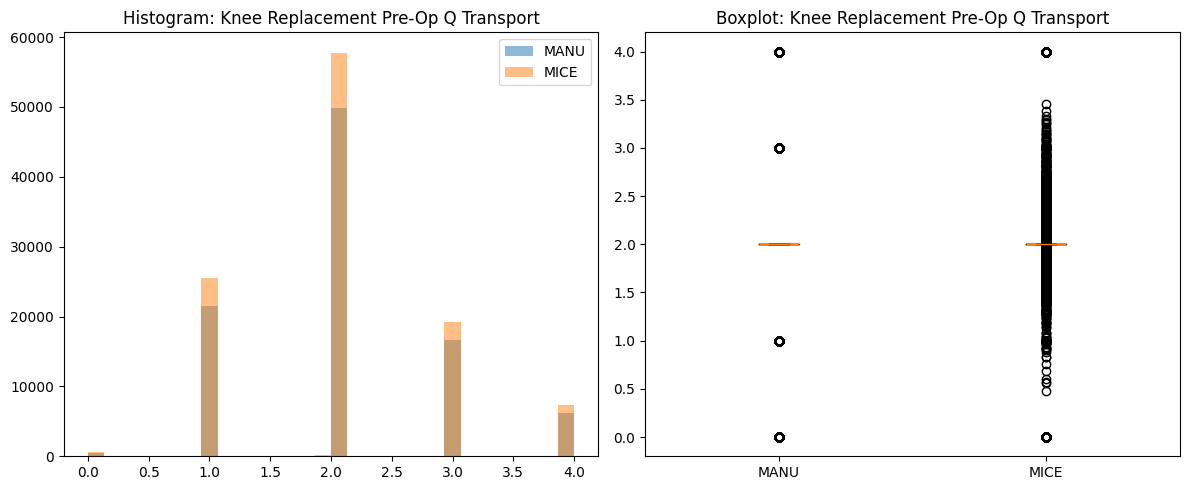

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


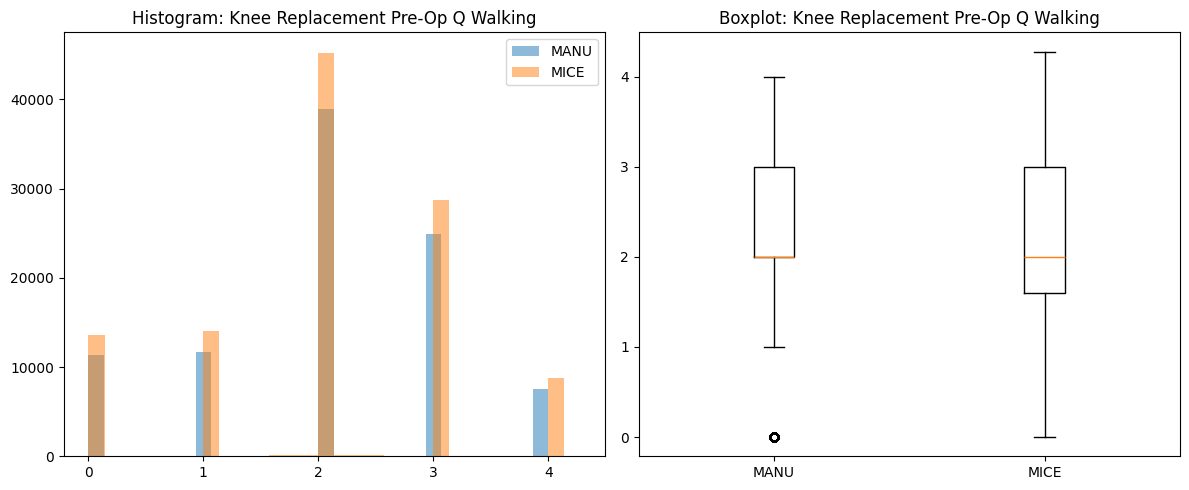

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


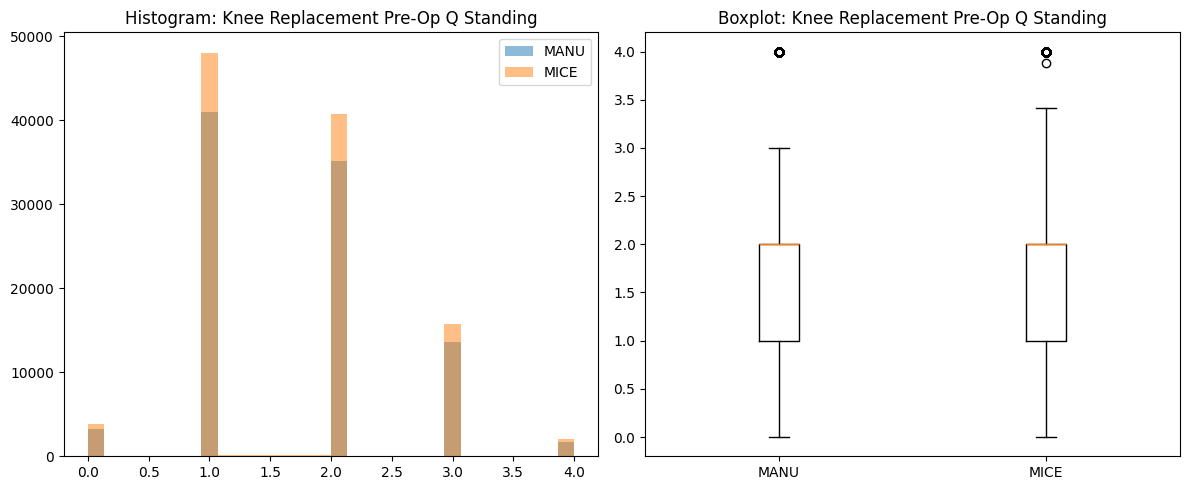

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


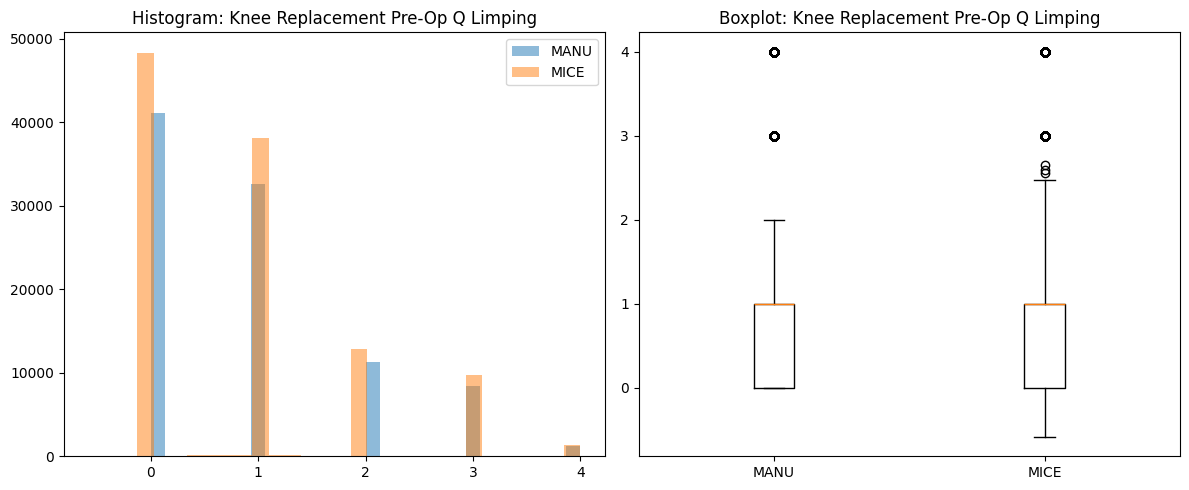

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


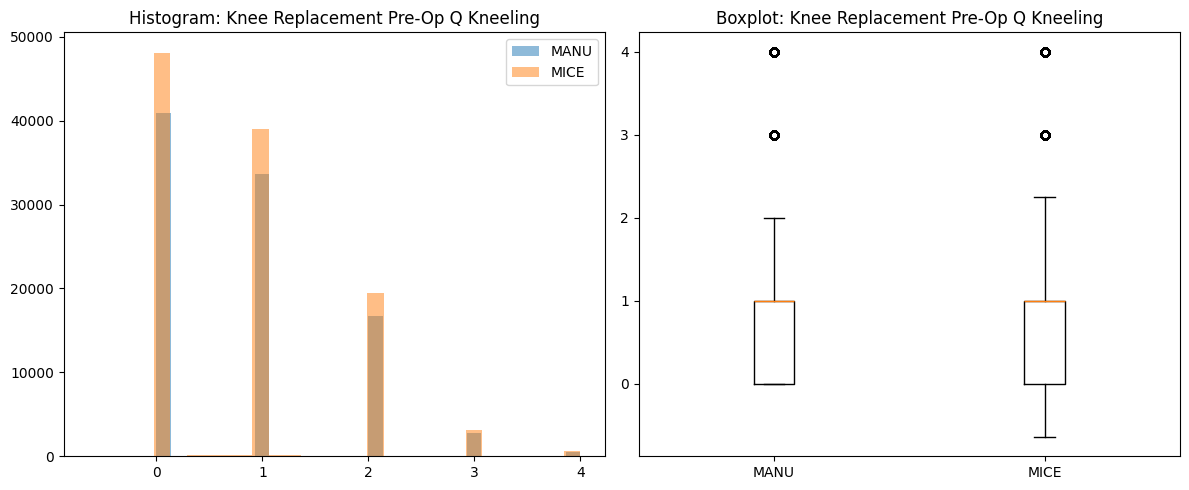

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


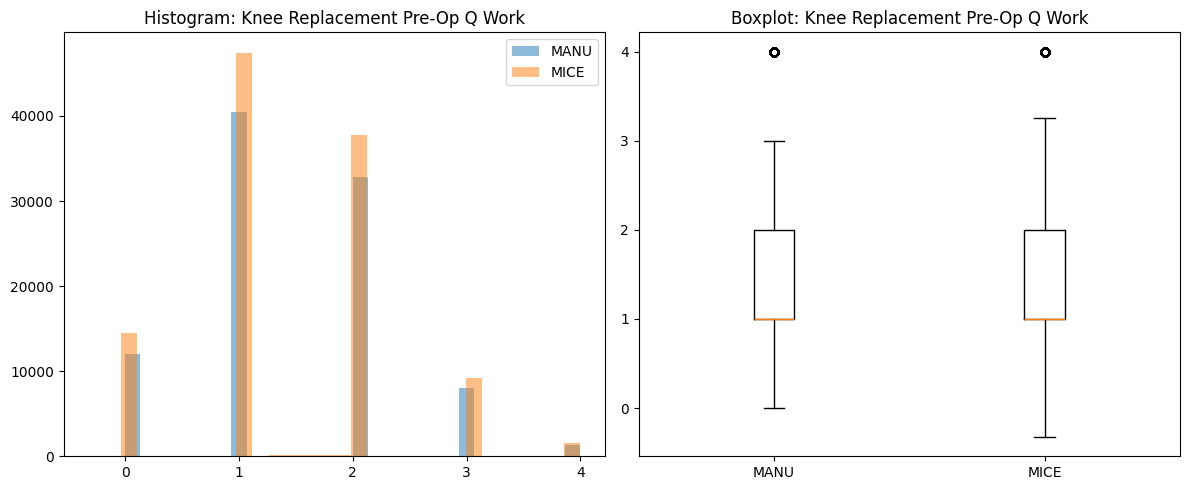

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


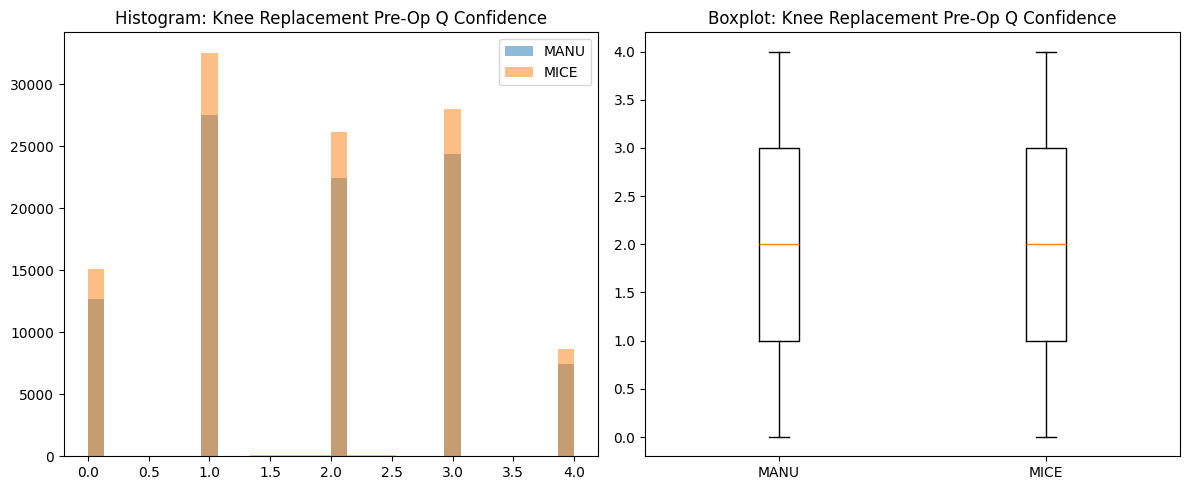

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


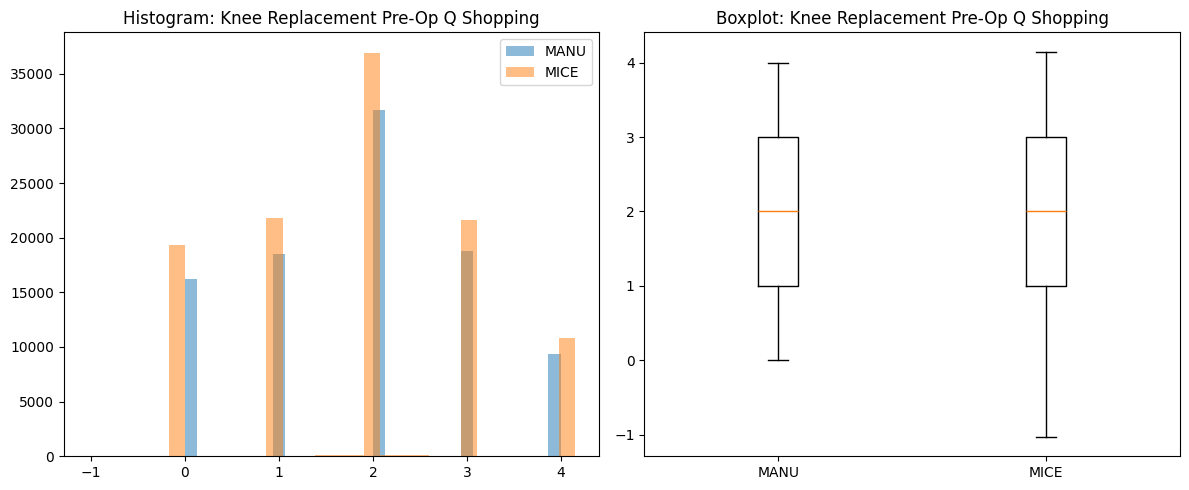

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


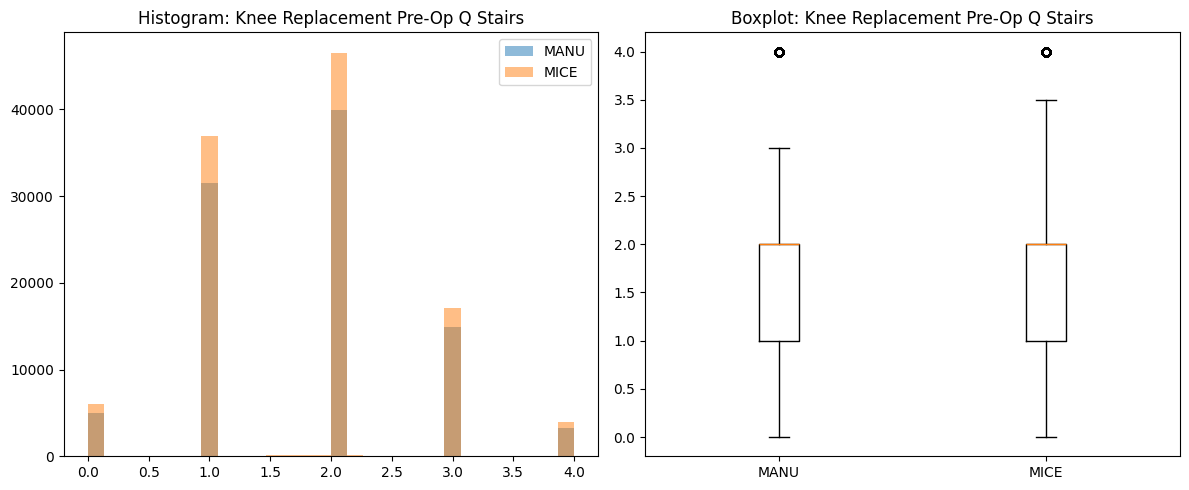

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12000\808833863.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])


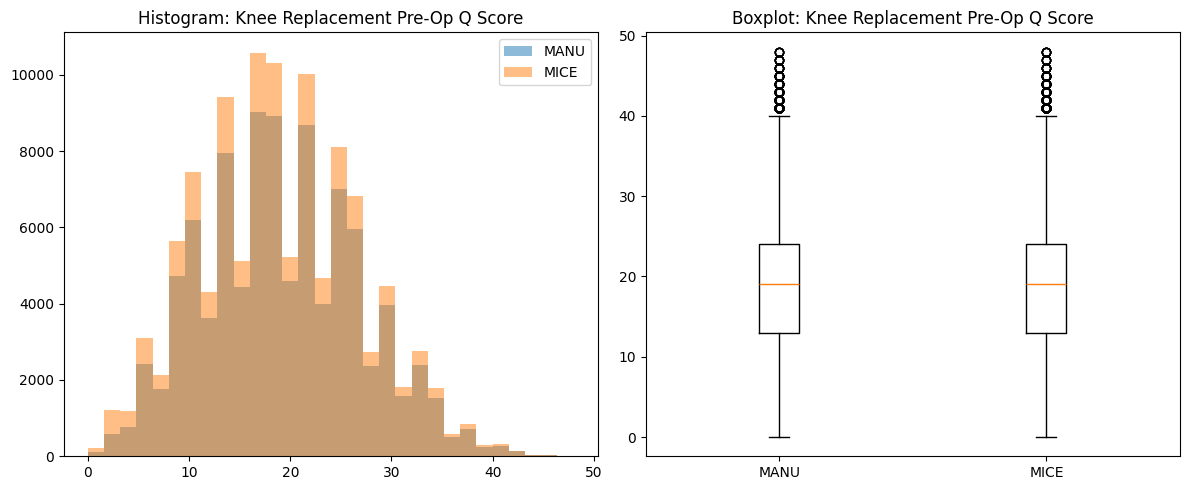

In [10]:

import polars as pl
import matplotlib.pyplot as plt

# Key numeric variables
key_numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs',
    'Knee Replacement Pre-Op Q Score'
]

# --- Summary statistics table ---
stats_manu = df_manu.select(
    [pl.col(v).mean().alias(f"{v}_mean_manu") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_manu") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_manu") for v in key_numeric_vars]
)

stats_mice = df_mice.select(
    [pl.col(v).mean().alias(f"{v}_mean_mice") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_mice") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_mice") for v in key_numeric_vars]
)

print("=== Summary Statistics: MANU ===")
print(stats_manu)

print("\n=== Summary Statistics: MICE ===")
print(stats_mice)


# --- Visual comparison: histograms + boxplots ---
for col in key_numeric_vars:
    manu_vals = df_manu[col].drop_nulls().to_numpy()
    mice_vals = df_mice[col].drop_nulls().to_numpy()

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(manu_vals, bins=30, alpha=0.5, label="MANU")
    plt.hist(mice_vals, bins=30, alpha=0.5, label="MICE")
    plt.title(f"Histogram: {col}")
    plt.legend()

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot([manu_vals, mice_vals], labels=["MANU", "MICE"])
    plt.title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()
